SENTINEL-1 LARGE IMAGE INFERENCE - SUMMIT (CPU MODE)
Initializing Summit components...
Detected Training Checkpoint structure.
✅ Loaded SUMMIT checkpoint (Epoch 99) on cpu
Found 13603 total large images.


Predicting (CPU):   0%|          | 0/10 [00:00<?, ?it/s]/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Predicting (CPU): 100%|██████████| 10/10 [03:04<00:00, 18.49s/it]



📊 Generating visualizations...


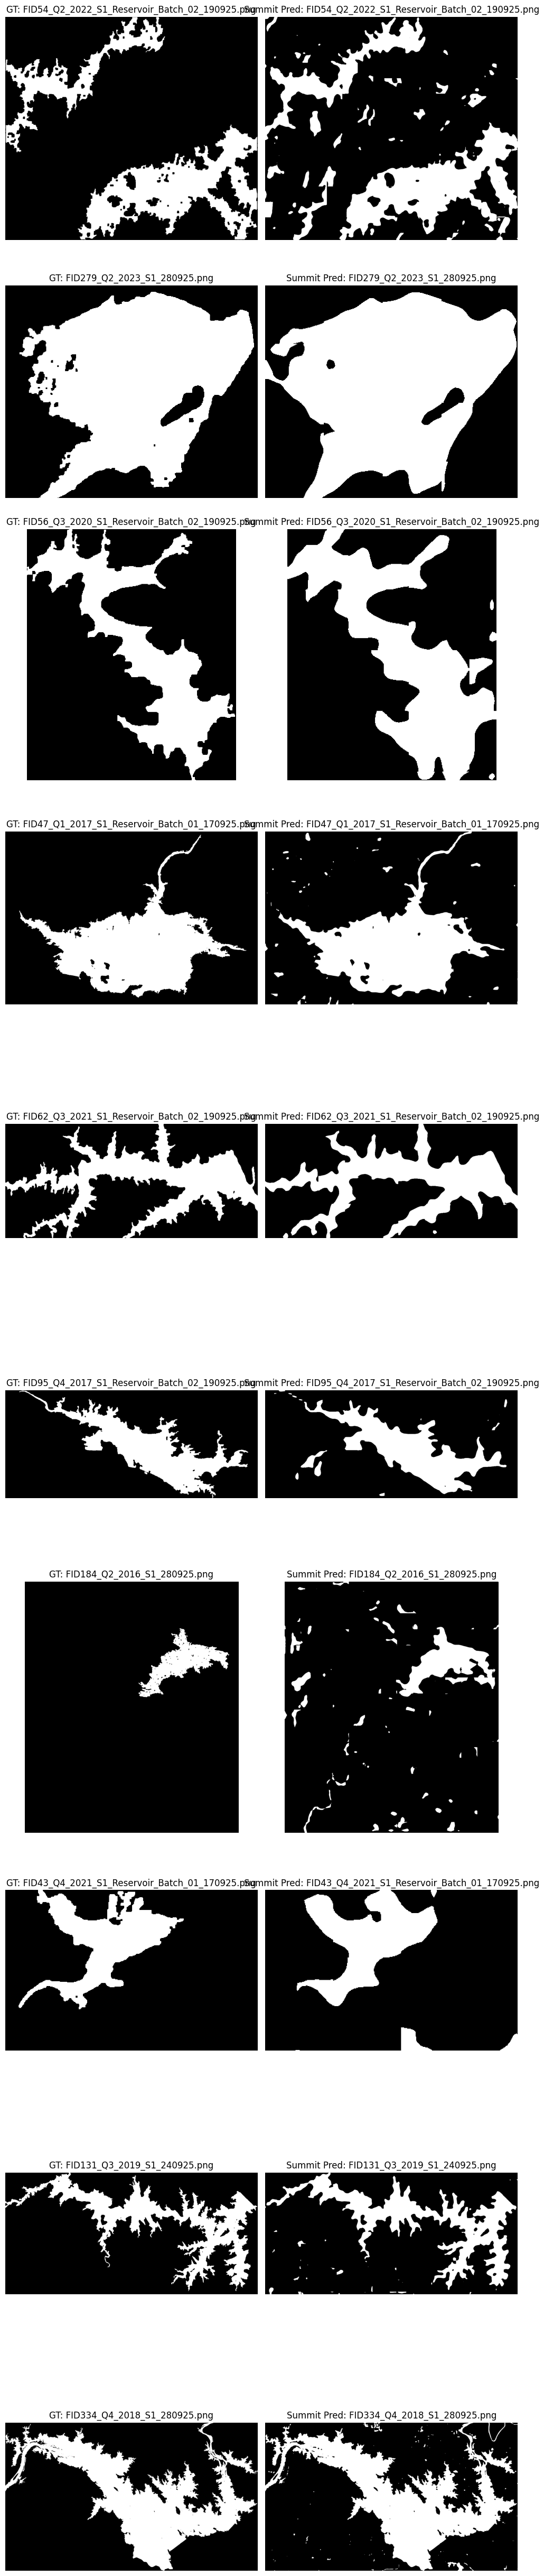


✅ Done!


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from tqdm import tqdm
import random

# SMP Imports
from segmentation_models_pytorch.decoders.upernet.decoder import UPerNetDecoder
from segmentation_models_pytorch.base import SegmentationHead

# --- MODIFIED: Import Summit/MAE dependencies ---
import mae_model

# ============================================================================
# CONFIGURATION
# ============================================================================

# --- 1. Point to your TRAINED SUMMIT CHECKPOINT
# Make sure this points to the checkpoint SAVED by your SegmentationTrainer (e.g., ckpt_epoch_10.pth)
CHECKPOINT_PATH = '/home/arm/Desktop/ARM/Codes/SUMMIT-SAR/checkpoints/Summit+UPerNet/best_model.pth' 

# --- 2. Point to your NEW, LARGE images
LARGE_IMAGE_VV_DIR = Path('/home/arm/Documents/ARM/8bit_png/vv')
LARGE_IMAGE_VH_DIR = Path('/home/arm/Documents/ARM/8bit_png/vh')
LARGE_IMAGE_LABELS_DIR = Path('/home/arm/Documents/ARM/8bit_png/labels')

# --- 3. Output directory
SAVE_DIR = 'inference_results_summit_cpu'

# --- 4. Model & Inference parameters
TILE_SIZE = 224
STRIDE = 112  
DEVICE = 'cpu'  # <--- Forced to CPU
NUM_CLASSES = 2
SEED = 103
NUM_IMAGES_TO_TEST = 10

# --- 5. Normalization constants (3 CHANNELS: VV, VH, AVG)
# These match your training code
S1_MEAN = torch.tensor([166.36, 88.45, 127.41], dtype=torch.float32).to(DEVICE)
S1_STD = torch.tensor([64.83, 43.07, 53.95], dtype=torch.float32).to(DEVICE)

# ============================================================================
# 1. MODEL DEFINITIONS (Corrected for Summit/MAE)
# ============================================================================

class ViTFeatureExtractor:
    def __init__(self, model):
        self.model = model
        self.features = {}
        self.hooks = []
        
        # Hook intermediate blocks
        self.hooks.append(model.blocks[3].register_forward_hook(self._get_hook('block_3')))
        self.hooks.append(model.blocks[5].register_forward_hook(self._get_hook('block_5')))
        self.hooks.append(model.blocks[7].register_forward_hook(self._get_hook('block_7')))
        
        # Hook the FINAL NORM layer (Crucial for MAE/Summit)
        self.hooks.append(model.norm.register_forward_hook(self._get_hook('norm')))

    def _get_hook(self, name):
        def hook(model, input, output):
            self.features[name] = output
        return hook

    def clear(self):
        self.features = {}

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

def extract_patch_features(model, images, feature_extractor):
    feature_extractor.clear()
    # mask_ratio=0 ensures the encoder sees the FULL image
    _ = model.forward_encoder(images, mask_ratio=0)
    return feature_extractor.features

class SummitUPerNet(nn.Module):
    def __init__(self, encoder_dim=768, decoder_channels=256, num_classes=2, patch_size=16, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        encoder_channels = [3, encoder_dim, encoder_dim, encoder_dim, encoder_dim]
        
        self.feature_proj = nn.ModuleDict({
            'block_3': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_5': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_7': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'norm':    nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False), # Key is 'norm'
        })
        
        self.decoder = UPerNetDecoder(
            encoder_channels=encoder_channels,
            encoder_depth=4,
            decoder_channels=decoder_channels,
            use_norm="batchnorm",
        )
        
        self.segmentation_head = SegmentationHead(
            in_channels=decoder_channels,
            out_channels=num_classes,
            activation=None,
            kernel_size=1,
            upsampling=4, 
        )
        self.dropout = nn.Dropout2d(dropout)
    
    def reshape_vit_features(self, features, H, W):
        B, N, D = features.shape
        # MAE has CLS token at index 0
        if N == (H * W) + 1: features = features[:, 1:, :]
        return features.transpose(1, 2).reshape(B, D, H, W)
    
    def forward(self, features_dict, target_size, dummy_input=None):
        B, N, D = features_dict['norm'].shape
        H = W = int(np.sqrt(N)) if N % int(np.sqrt(N)) == 0 else int(np.sqrt(N - 1))
        
        feat_3 = self.feature_proj['block_3'](self.reshape_vit_features(features_dict['block_3'], H, W))
        feat_5 = self.feature_proj['block_5'](self.reshape_vit_features(features_dict['block_5'], H, W))
        feat_7 = self.feature_proj['block_7'](self.reshape_vit_features(features_dict['block_7'], H, W))
        feat_11 = self.feature_proj['norm'](self.reshape_vit_features(features_dict['norm'], H, W))
        
        if dummy_input is None: dummy_input = torch.zeros(B, 3, H, H, device=feat_3.device)
        else: dummy_input = F.interpolate(dummy_input, size=(H, H), mode='bilinear', align_corners=False)
        
        features_list = [dummy_input, feat_3, feat_5, feat_7, feat_11]
        x = self.segmentation_head(self.dropout(self.decoder(features_list)))
        return F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

# ============================================================================
# 2. SUMMIT WRAPPER
# ============================================================================

class SummitPredictor(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        # Uses the specific Summit Extractor hook
        self.extractor = ViTFeatureExtractor(self.encoder)
        
    def forward(self, images):
        features_dict = extract_patch_features(self.encoder, images, self.extractor)
        target_size = images.shape[-2:]
        logits = self.decoder(features_dict, target_size, dummy_input=images)
        return logits

# ============================================================================
# 3. HELPER FUNCTIONS
# ============================================================================

def load_summit_checkpoint(checkpoint_path, predictor, device='cpu'):
    """Load FINETUNED Summit weights (Mapping GPU weights to CPU)"""
    
    # 1. Load the dictionary
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # 2. Handle if it's a full checkpoint dict or just state dict (robustness)
    # The SegmentationTrainer saves keys: 'encoder_state_dict', 'decoder_state_dict'
    if 'encoder_state_dict' in checkpoint:
        print("Detected Training Checkpoint structure.")
        predictor.encoder.load_state_dict(checkpoint['encoder_state_dict'])
        predictor.decoder.load_state_dict(checkpoint['decoder_state_dict'])
    else:
        print("⚠️ Warning: Unexpected checkpoint structure. Trying direct load...")
        predictor.load_state_dict(checkpoint)
    
    predictor = predictor.to(device)
    predictor.eval()
    
    epoch_info = checkpoint.get('epoch', 'Unknown')
    print(f"✅ Loaded SUMMIT checkpoint (Epoch {epoch_info}) on {device}")
    return predictor

def normalize_tensor(tensor):
    # Expects tensor shape (3, H, W) or (B, 3, H, W)
    mean = S1_MEAN.view(3, 1, 1)
    std = S1_STD.view(3, 1, 1)
    return (tensor - mean) / std

def predict_large_image(model, vv_path, vh_path, tile_size, stride, device):
    model.eval()

    # 1. Read Data
    with rasterio.open(vv_path) as f_vv:
        vv = f_vv.read(1).astype('float32')
        H_orig, W_orig = vv.shape
    with rasterio.open(vh_path) as f_vh:
        vh = f_vh.read(1).astype('float32')

    # 2. Create 3rd Channel (Avg) - Required for Summit
    avg = (vv + vh) / 2.0

    # 3. Stack to 3 Channels
    image = np.stack([vv, vh, avg], axis=0) 
    
    # 4. Normalize
    image_tensor = torch.from_numpy(image).to(device)
    image_tensor = normalize_tensor(image_tensor)

    # --- Small image logic ---
    if H_orig < tile_size or W_orig < tile_size:
        image_tensor = image_tensor.unsqueeze(0)
        with torch.no_grad():
            resized_image = F.interpolate(image_tensor, size=(tile_size, tile_size), mode='bilinear', align_corners=False)
            logits = model(resized_image) 
            probs = torch.softmax(logits, dim=1)
            orig_size_probs = F.interpolate(probs, size=(H_orig, W_orig), mode='bilinear', align_corners=False)
            final_prediction = torch.argmax(orig_size_probs.squeeze(0), dim=0)
        return final_prediction.cpu().numpy()
        
    # --- Sliding window logic ---
    else:
        pad_w = (stride - (W_orig - tile_size) % stride) % stride
        pad_h = (stride - (H_orig - tile_size) % stride) % stride
        
        image_tensor = F.pad(image_tensor, (0, pad_w, 0, pad_h), mode='replicate') 
        
        C, H_padded, W_padded = image_tensor.shape
        
        prediction_sum = torch.zeros((NUM_CLASSES, H_padded, W_padded), dtype=torch.float32).to(device)
        pixel_counts = torch.zeros((1, H_padded, W_padded), dtype=torch.float32).to(device)

        with torch.no_grad():
            for y in range(0, H_padded - tile_size + 1, stride):
                for x in range(0, W_padded - tile_size + 1, stride):
                    # Get tile (3, 224, 224)
                    tile = image_tensor[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)
                    
                    logits = model(tile)
                    
                    probs = torch.softmax(logits, dim=1)
                    prediction_sum[:, y:y+tile_size, x:x+tile_size] += probs.squeeze(0)
                    pixel_counts[:, y:y+tile_size, x:x+tile_size] += 1

        avg_probs = prediction_sum / (pixel_counts + 1e-6)
        final_prediction_padded = torch.argmax(avg_probs, dim=0)
        final_prediction = final_prediction_padded[0:H_orig, 0:W_orig]
        
        return final_prediction.cpu().numpy()

def visualize_stitched_results(results_list, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    num_images = len(results_list)
    if num_images == 0:
        print("No results to visualize.")
        return

    fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))
    if num_images == 1: axes = np.array([axes])

    for idx, result in enumerate(results_list):
        ax_gt = axes[idx, 0]
        ax_gt.imshow(result['ground_truth'], cmap='gray', vmin=0, vmax=1)
        ax_gt.set_title(f"GT: {result['name']}")
        ax_gt.axis('off')

        ax_pred = axes[idx, 1]
        ax_pred.imshow(result['prediction'], cmap='gray', vmin=0, vmax=1)
        ax_pred.set_title(f"Summit Pred: {result['name']}")
        ax_pred.axis('off')

    plt.tight_layout()
    # save_path = os.path.join(save_dir, 'stitched_inference_comparison.png')
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("SENTINEL-1 LARGE IMAGE INFERENCE - SUMMIT (CPU MODE)")
print("=" * 60)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Initializing Summit components...")
# Initialize standard MAE
encoder = mae_model.mae_vit_base_patch16(img_size=TILE_SIZE)

decoder = SummitUPerNet(
    encoder_dim=768,
    decoder_channels=256,
    num_classes=NUM_CLASSES,
    patch_size=16
)

model_wrapper = SummitPredictor(encoder, decoder)

# Load your finetuned weights
model_wrapper = load_summit_checkpoint(CHECKPOINT_PATH, model_wrapper, DEVICE)

all_vv_paths = sorted(list(LARGE_IMAGE_VV_DIR.glob('*.png')))
print(f"Found {len(all_vv_paths)} total large images.")

if len(all_vv_paths) > NUM_IMAGES_TO_TEST:
    vv_paths_to_run = random.sample(all_vv_paths, NUM_IMAGES_TO_TEST)
else:
    vv_paths_to_run = all_vv_paths

results_list = []

for vv_path in tqdm(vv_paths_to_run, desc="Predicting (CPU)"):
    basename = vv_path.name
    label_match = list(LARGE_IMAGE_LABELS_DIR.glob(f"{vv_path.stem}*.png"))
    vh_path = LARGE_IMAGE_VH_DIR / basename
    
    if not vh_path.exists(): continue
    if not label_match: continue
        
    label_path = label_match[0]

    prediction_mask = predict_large_image(
        model=model_wrapper,
        vv_path=vv_path,
        vh_path=vh_path,
        tile_size=TILE_SIZE,
        stride=STRIDE,
        device=DEVICE
    )

    with rasterio.open(label_path) as f:
        # Read(1) to get 2D mask
        label_raw = f.read(1)
        ground_truth = np.where(label_raw > 128, 1, 0).astype('uint8')

    results_list.append({
        'prediction': prediction_mask,
        'ground_truth': ground_truth,
        'name': basename
    })

if results_list:
    print("\n📊 Generating visualizations...")
    visualize_stitched_results(results_list, SAVE_DIR)

print(f"\n✅ Done!")

In [ ]:
import torch
torch.cuda.empty_cache()

In [1]:
import os
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from collections import defaultdict
import rasterio
from scipy.ndimage import label
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.decoders.upernet.decoder import UPerNetDecoder
from segmentation_models_pytorch.base import SegmentationHead
from tqdm import tqdm
import warnings
import gc
import random

# --- IMPORT YOUR MAE MODEL ---
# Ensure mae_model.py is in the same directory
import mae_model

warnings.filterwarnings('ignore')

# ============================================================================
# 1. CONFIGURATION
# ============================================================================

# --- Model Config ---
# Path to your SUMMIT/MAE checkpoint
CHECKPOINT_PATH = '/home/arm/Desktop/ARM/Codes/SUMMIT-SAR/checkpoints/Summit+UPerNet/best_model.pth' 
NUM_CLASSES = 2

# --- Inference Parameters ---
TILE_SIZE = 224
STRIDE = 112 
SEED = 103

# --- Input Directories (Validation Data) ---
PNG_VV_DIR = Path('/home/arm/Documents/ARM/8bit_png/validation/vv')
PNG_VH_DIR = Path('/home/arm/Documents/ARM/8bit_png/validation/vh')
ORIGINAL_TIFF_DIR = Path('/home/arm/Documents/ARM/Validation')
SLOPE_DIR = Path('/data/ARM_Dataset/Copernicus_Slope_UINT16')

# --- Output Directory ---
OUTPUT_PLOT_DIR = "/home/arm/Documents/ARM/validation_plots_summit"

# --- Visualization Config ---
BAND_CONFIG = {'red': 2, 'green': 7, 'blue': 3}
MAX_ROWS = 4
MAX_COLS = 8 

# --- Normalization Constants (3 CHANNELS: VV, VH, AVG) ---
# Summit uses 3 channels. We compute the 3rd channel on the fly.
S1_MEAN = torch.tensor([166.36, 88.45, 127.41], dtype=torch.float32)
S1_STD = torch.tensor([64.83, 43.07, 53.95], dtype=torch.float32)

# ============================================================================
# 2. SUMMIT MODEL ARCHITECTURE
# ============================================================================

class ViTFeatureExtractor:
    def __init__(self, model):
        self.model = model
        self.features = {}
        self.hooks = []
        
        # Hook intermediate blocks
        self.hooks.append(model.blocks[3].register_forward_hook(self._get_hook('block_3')))
        self.hooks.append(model.blocks[5].register_forward_hook(self._get_hook('block_5')))
        self.hooks.append(model.blocks[7].register_forward_hook(self._get_hook('block_7')))
        
        # Hook the FINAL NORM layer (Crucial for MAE/Summit)
        self.hooks.append(model.norm.register_forward_hook(self._get_hook('norm')))

    def _get_hook(self, name):
        def hook(model, input, output):
            self.features[name] = output
        return hook

    def clear(self):
        self.features = {}

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

def extract_patch_features(model, images, feature_extractor):
    feature_extractor.clear()
    # mask_ratio=0 ensures the encoder sees the FULL image
    _ = model.forward_encoder(images, mask_ratio=0)
    return feature_extractor.features

class SummitUPerNet(nn.Module):
    def __init__(self, encoder_dim=768, decoder_channels=256, num_classes=2, patch_size=16, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        encoder_channels = [3, encoder_dim, encoder_dim, encoder_dim, encoder_dim]
        
        self.feature_proj = nn.ModuleDict({
            'block_3': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_5': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_7': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'norm':    nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False), # Key is 'norm'
        })
        
        self.decoder = UPerNetDecoder(
            encoder_channels=encoder_channels,
            encoder_depth=4,
            decoder_channels=decoder_channels,
            use_norm="batchnorm",
        )
        
        self.segmentation_head = SegmentationHead(
            in_channels=decoder_channels,
            out_channels=num_classes,
            activation=None,
            kernel_size=1,
            upsampling=4, 
        )
        self.dropout = nn.Dropout2d(dropout)
    
    def reshape_vit_features(self, features, H, W):
        B, N, D = features.shape
        # MAE has CLS token at index 0, so we skip it [:, 1:, :]
        if N == (H * W) + 1: features = features[:, 1:, :]
        return features.transpose(1, 2).reshape(B, D, H, W)
    
    def forward(self, features_dict, target_size, dummy_input=None):
        B, N, D = features_dict['norm'].shape
        H = W = int(np.sqrt(N)) if N % int(np.sqrt(N)) == 0 else int(np.sqrt(N - 1))
        
        feat_3 = self.feature_proj['block_3'](self.reshape_vit_features(features_dict['block_3'], H, W))
        feat_5 = self.feature_proj['block_5'](self.reshape_vit_features(features_dict['block_5'], H, W))
        feat_7 = self.feature_proj['block_7'](self.reshape_vit_features(features_dict['block_7'], H, W))
        feat_11 = self.feature_proj['norm'](self.reshape_vit_features(features_dict['norm'], H, W))
        
        if dummy_input is None: dummy_input = torch.zeros(B, 3, H, H, device=feat_3.device)
        else: dummy_input = F.interpolate(dummy_input, size=(H, H), mode='bilinear', align_corners=False)
        
        features_list = [dummy_input, feat_3, feat_5, feat_7, feat_11]
        x = self.segmentation_head(self.dropout(self.decoder(features_list)))
        return F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

class SummitPredictor(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.extractor = ViTFeatureExtractor(self.encoder)
        
    def forward(self, images):
        features_dict = extract_patch_features(self.encoder, images, self.extractor)
        target_size = images.shape[-2:]
        logits = self.decoder(features_dict, target_size, dummy_input=images)
        return logits

# ============================================================================
# 3. UTILITIES
# ============================================================================

def extract_fid_info(filename):
    match = re.search(r'FID(\d+)_Q(\d)_(\d{4})', filename, re.IGNORECASE)
    if match: return int(match.group(1)), int(match.group(2)), int(match.group(3))
    match = re.search(r'id(\d+)_Q(\d)_(\d{4})', filename, re.IGNORECASE)
    if match: return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return None, None, None

def get_expected_output_files(fid, n_timepoints):
    images_per_plot = MAX_ROWS * 2
    n_plots = (n_timepoints + images_per_plot - 1) // images_per_plot
    files = []
    if n_plots > 1:
        for part in range(1, n_plots + 1):
            files.append(f'ID{fid:03d}_part{part:02d}.png')
    else:
        files.append(f'ID{fid:03d}_temporal.png')
    return files

def check_fid_completed(fid, n_timepoints, output_dir):
    expected_files = get_expected_output_files(fid, n_timepoints)
    output_path = Path(output_dir)
    for fname in expected_files:
        if not (output_path / fname).exists(): return False
    return True

def flush_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

# ============================================================================
# 4. PREDICTOR CLASS (SUMMIT SPECIFIC)
# ============================================================================

class OptimizedSummitPredictor:
    """Wrapper class to handle Summit/MAE loading and inference logic"""
    
    def __init__(self, checkpoint_path, device):
        self.device = device
        self.mean = S1_MEAN.to(device).view(1, 3, 1, 1)
        self.std = S1_STD.to(device).view(1, 3, 1, 1)
        self._load_model(checkpoint_path)

    def _load_model(self, checkpoint_path):
        print(f"Loading SUMMIT model from {checkpoint_path}...")
        
        # 1. Initialize Architecture
        encoder = mae_model.mae_vit_base_patch16(img_size=TILE_SIZE)
        decoder = SummitUPerNet(
            encoder_dim=768,
            decoder_channels=256,
            num_classes=NUM_CLASSES,
            patch_size=16
        )
        
        # 2. Wrap
        self.model = SummitPredictor(encoder, decoder)
        
        # 3. Load Weights (Safe loading for CPU/GPU)
        checkpoint = torch.load(checkpoint_path, map_location=self.device, weights_only=False)
        
        if 'encoder_state_dict' in checkpoint:
            self.model.encoder.load_state_dict(checkpoint['encoder_state_dict'])
            self.model.decoder.load_state_dict(checkpoint['decoder_state_dict'])
        else:
            self.model.load_state_dict(checkpoint)
        
        self.model = self.model.to(self.device)
        self.model.eval()

    def normalize_tensor(self, tensor):
        # Expects (3, H, W) input
        mean = S1_MEAN.to(self.device).view(3, 1, 1)
        std = S1_STD.to(self.device).view(3, 1, 1)
        return (tensor - mean) / std

    @torch.inference_mode()
    def predict(self, vv_path, vh_path):
        """
        Runs Summit inference. 
        Requires creating a 3rd channel (Avg) and 3-channel normalization.
        """
        # 1. Read Image
        with rasterio.open(vv_path) as f:
            vv = f.read(1).astype('float32')
            H_orig, W_orig = vv.shape
        with rasterio.open(vh_path) as f:
            vh = f.read(1).astype('float32')

        # 2. Preprocess: Create 3 Channels (VV, VH, Avg)
        avg = (vv + vh) / 2.0
        image_np = np.stack([vv, vh, avg], axis=0)
        
        image_tensor = torch.from_numpy(image_np).to(self.device)
        image_tensor = self.normalize_tensor(image_tensor) # (3, H, W)

        # 3. Inference Strategy
        
        # Case A: Small Image
        if H_orig < TILE_SIZE or W_orig < TILE_SIZE:
            image_tensor = image_tensor.unsqueeze(0) # (1, 3, H, W)
            resized_image = F.interpolate(image_tensor, size=(TILE_SIZE, TILE_SIZE), mode='bilinear', align_corners=False)
            logits = self.model(resized_image) 
            probs = torch.softmax(logits, dim=1)
            orig_size_probs = F.interpolate(probs, size=(H_orig, W_orig), mode='bilinear', align_corners=False)
            final_prediction = torch.argmax(orig_size_probs.squeeze(0), dim=0)
            
            del image_tensor, resized_image, logits, probs
            return final_prediction.cpu().numpy().astype(np.uint8)

        # Case B: Sliding Window
        else:
            pad_w = (STRIDE - (W_orig - TILE_SIZE) % STRIDE) % STRIDE
            pad_h = (STRIDE - (H_orig - TILE_SIZE) % STRIDE) % STRIDE
            
            # (1, 3, H_pad, W_pad)
            padded_image = F.pad(image_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode='replicate')
            
            _, C, H_padded, W_padded = padded_image.shape
            
            prediction_sum = torch.zeros((NUM_CLASSES, H_padded, W_padded), dtype=torch.float32, device=self.device)
            pixel_counts = torch.zeros((1, H_padded, W_padded), dtype=torch.float32, device=self.device)

            # Slide
            for y in range(0, H_padded - TILE_SIZE + 1, STRIDE):
                for x in range(0, W_padded - TILE_SIZE + 1, STRIDE):
                    # Extract tile: (1, 3, 224, 224)
                    tile = padded_image[:, :, y:y+TILE_SIZE, x:x+TILE_SIZE]
                    
                    logits = self.model(tile)
                    probs = torch.softmax(logits, dim=1)
                    
                    prediction_sum[:, y:y+TILE_SIZE, x:x+TILE_SIZE] += probs.squeeze(0)
                    pixel_counts[:, y:y+TILE_SIZE, x:x+TILE_SIZE] += 1

            avg_probs = prediction_sum / (pixel_counts + 1e-6)
            final_prediction_padded = torch.argmax(avg_probs, dim=0)
            
            # Crop back to original size
            final_prediction = final_prediction_padded[0:H_orig, 0:W_orig]
            
            del padded_image, prediction_sum, pixel_counts, avg_probs
            flush_memory()
            
            return final_prediction.cpu().numpy().astype(np.uint8)

# ============================================================================
# 5. POST-PROCESSING (SLOPE & MMU)
# ============================================================================

def apply_slope_cleaning(prediction_mask, slope_path, fid):
    slope_file = slope_path / f"COPERNICUS_FID_{fid}_resampled.tif"
    if not slope_file.exists(): return prediction_mask
    try:
        with rasterio.open(slope_file) as src:
            slope_data = src.read(1)
        if slope_data.shape != prediction_mask.shape: return prediction_mask
        
        cleaned = prediction_mask.copy()
        water_mask = (prediction_mask == 1)
        slope_high_mask = (slope_data >= 300)
        cleaned[water_mask & slope_high_mask] = 0
        return cleaned
    except:
        return prediction_mask

def find_optimal_threshold_2bin_gap(region_sizes, num_features):
    max_size = region_sizes.max()
    num_bins = min(50, max(20, num_features // 5))
    hist, bin_edges = np.histogram(region_sizes, bins=num_bins)
    
    two_bin_gaps = []
    for i in range(len(hist) - 1):
        if i + 1 < len(hist) and hist[i] == 0 and hist[i + 1] == 0:
            is_start = (i == 0 or hist[i - 1] > 0)
            is_end = (i + 2 >= len(hist) or hist[i + 2] > 0)
            if is_start and is_end:
                start_value = bin_edges[i]
                end_value = bin_edges[i + 2]
                center = (start_value + end_value) / 2
                has_data_before = i > 0 and hist[i - 1] > 0
                has_data_after = i + 1 < len(hist) - 1 and hist[i + 2] > 0
                if has_data_before and has_data_after and center < max_size * 0.8:
                    two_bin_gaps.append({'start_value': start_value, 'center': center})
    
    if len(two_bin_gaps) > 0:
        two_bin_gaps.sort(key=lambda x: x['center'])
        gap_threshold = two_bin_gaps[0]['start_value']
    else:
        gap_threshold = np.percentile(region_sizes, 20)
    
    p10 = np.percentile(region_sizes, 10)
    return max(gap_threshold, p10), max_size

def apply_mmu_cleaning(slope_cleaned_mask):
    structure = np.ones((3, 3), dtype=int)
    labeled_array, num_features = label(slope_cleaned_mask == 1, structure=structure)
    
    if num_features < 2: return slope_cleaned_mask
    
    region_sizes = np.bincount(labeled_array.ravel())[1:]
    gap_threshold, max_component_size = find_optimal_threshold_2bin_gap(region_sizes, num_features)
    final_threshold = max(gap_threshold, max_component_size * 0.10)
    
    filtered_labels = labeled_array.copy()
    removed_count = 0
    for region_id in range(1, num_features + 1):
        if region_sizes[region_id - 1] < final_threshold:
            filtered_labels[filtered_labels == region_id] = 0
            removed_count += 1
            
    # Fallback protections (keep at least top 2)
    kept_count = num_features - removed_count
    if kept_count < 2:
        component_sizes = [(i+1, region_sizes[i]) for i in range(len(region_sizes))]
        component_sizes.sort(key=lambda x: x[1], reverse=True)
        top_labels = [x[0] for x in component_sizes[:min(2, len(component_sizes))]]
        filtered_labels = labeled_array.copy()
        for region_id in range(1, num_features + 1):
            if region_id not in top_labels:
                filtered_labels[filtered_labels == region_id] = 0
                
    cleaned_image = (filtered_labels > 0).astype(np.uint8)
    return cleaned_image

# ============================================================================
# 6. PLOTTING & MAIN PIPELINE
# ============================================================================

def read_tiff_as_rgb(tiff_path, band_config):
    try:
        with rasterio.open(tiff_path) as src:
            if src.count < max(band_config.values()): return None
            bands = [src.read(band_config[c]).astype(float) for c in ['red', 'green', 'blue']]
            rgb_list = []
            for band in bands:
                valid = band[np.isfinite(band)]
                if len(valid) > 0:
                    vmin, vmax = np.percentile(valid, [2, 98])
                    normed = np.clip((band - vmin) / (vmax - vmin + 1e-8), 0, 1)
                else:
                    normed = np.zeros_like(band)
                rgb_list.append(normed)
            return np.dstack(rgb_list)
    except:
        return None

def organize_temporal_sequence(fid_data):
    years = defaultdict(list)
    for (year, quarter), paths in fid_data.items():
        years[year].append((quarter, paths))
    for year in years: years[year].sort(key=lambda x: x[0])
    
    sorted_years = sorted(years.keys())
    sequence = []
    for year in sorted_years:
        for quarter, paths in years[year]:
            sequence.append((year, quarter, paths))
    return sequence

def create_temporal_plots(fid, sequence, predictor, slope_dir, output_dir, band_config):
    n_timepoints = len(sequence)
    if n_timepoints == 0: return

    first_tif = sequence[0][2]['tiff']
    with rasterio.open(first_tif) as src:
        aspect = src.width / max(src.height, 1)

    images_per_plot = MAX_ROWS * 2
    chunks = [sequence[i:i + images_per_plot] for i in range(0, n_timepoints, images_per_plot)]
    total_parts = len(chunks)

    for part_idx, chunk in enumerate(chunks):
        part_num = part_idx + 1
        out_name = f'ID{fid:03d}_part{part_num:02d}.png' if total_parts > 1 else f'ID{fid:03d}_temporal.png'
        out_path = Path(output_dir) / out_name
        
        if out_path.exists(): continue

        n_rows = (len(chunk) + 1) // 2
        unit_width = 2.5
        fig_width = (unit_width * 8) + 1
        fig_height = (unit_width / aspect * n_rows) + 1.5

        fig = plt.figure(figsize=(fig_width, fig_height))
        gs = GridSpec(n_rows, 8, figure=fig, wspace=0.03, hspace=0.12,
                      left=0.02, right=0.98, top=0.94, bottom=0.02)

        for idx, (year, quarter, paths) in enumerate(chunk):
            row = idx // 2
            col_set = (idx % 2) * 4
            
            # 1. RGB
            rgb_img = read_tiff_as_rgb(paths['tiff'], band_config)
            ax_rgb = fig.add_subplot(gs[row, col_set])
            if rgb_img is not None: ax_rgb.imshow(rgb_img, aspect='equal')
            else: ax_rgb.text(0.5, 0.5, "Error", ha='center', fontsize=6)
            ax_rgb.axis('off')
            ax_rgb.set_title(f"Q{quarter} {year}\nRGB", fontsize=7, pad=2)
            
            # 2. Summit Prediction
            pred_mask = predictor.predict(paths['vv_png'], paths['vh_png'])
            ax_pred = fig.add_subplot(gs[row, col_set + 1])
            ax_pred.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1, aspect='equal')
            ax_pred.axis('off')
            ax_pred.set_title(f"Pred (Summit)", fontsize=7, pad=2)
            
            # 3. Slope Clean
            slope_cleaned = apply_slope_cleaning(pred_mask, slope_dir, fid)
            ax_slope = fig.add_subplot(gs[row, col_set + 2])
            ax_slope.imshow(slope_cleaned, cmap='Greens', vmin=0, vmax=1, aspect='equal')
            ax_slope.axis('off')
            ax_slope.set_title(f"Slope", fontsize=7, pad=2)
            
            # 4. MMU Clean
            mmu_cleaned = apply_mmu_cleaning(slope_cleaned)
            ax_mmu = fig.add_subplot(gs[row, col_set + 3])
            ax_mmu.imshow(mmu_cleaned, cmap='Reds', vmin=0, vmax=1, aspect='equal')
            ax_mmu.axis('off')
            ax_mmu.set_title(f"MMU", fontsize=7, pad=2)
            
            del rgb_img, pred_mask, slope_cleaned, mmu_cleaned
            if (idx + 1) % 2 == 0: flush_memory()

        title_text = f"ID {fid} - Temporal Analysis (Summit)"
        if total_parts > 1: title_text += f" (Part {part_num}/{total_parts})"
        plt.suptitle(title_text, fontsize=13, fontweight='bold', y=0.98)
        
        plt.savefig(out_path, dpi=150, bbox_inches='tight', pad_inches=0.1)
        plt.close(fig)
        flush_memory()

def main():
    output_path = Path(OUTPUT_PLOT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)
    
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    # Use CPU if forced, otherwise CUDA
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print("=" * 80)
    print("VALIDATION PIPELINE - SUMMIT MODEL")
    print("=" * 80)
    print(f"Device: {device}")
    
    # 1. Discovery
    print("\n[1/4] Scanning files...")
    tiff_map = {}
    for f in ORIGINAL_TIFF_DIR.glob("*.tif"):
        fid, q, y = extract_fid_info(f.name)
        if fid: tiff_map[(fid, y, q)] = f
    
    fid_data = defaultdict(lambda: defaultdict(dict))
    for vv in PNG_VV_DIR.glob("*.png"):
        fid, q, y = extract_fid_info(vv.name)
        if not fid or (fid, y, q) not in tiff_map: continue
        vh = PNG_VH_DIR / vv.name.replace("_VV", "_VH")
        if vh.exists():
            fid_data[fid][(y, q)] = {'tiff': tiff_map[(fid, y, q)], 'vv_png': vv, 'vh_png': vh}

    fids_to_process = []
    skipped_count = 0
    for fid in sorted(fid_data.keys()):
        if check_fid_completed(fid, len(fid_data[fid]), output_path): skipped_count += 1
        else: fids_to_process.append(fid)

    print(f"  Found {len(fid_data)} FIDs. Skipped {skipped_count}. To process {len(fids_to_process)}.")
    
    if not fids_to_process: return

    # 2. Load Summit
    print("\n[2/4] Loading SUMMIT model...")
    predictor = OptimizedSummitPredictor(CHECKPOINT_PATH, device)
    
    # 3. Process
    print("\n[3/4] Processing FIDs...")
    for fid in tqdm(fids_to_process, desc="Processing"):
        try:
            sequence = organize_temporal_sequence(fid_data[fid])
            create_temporal_plots(fid, sequence, predictor, SLOPE_DIR, output_path, BAND_CONFIG)
        except Exception as e:
            print(f"Error on FID {fid}: {e}")
            continue

    print("\n[4/4] Complete!")

if __name__ == "__main__":
    main()

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VALIDATION PIPELINE - SUMMIT MODEL
Device: cuda

[1/4] Scanning files...
  Found 88 FIDs. Skipped 39. To process 49.

[2/4] Loading SUMMIT model...
Loading SUMMIT model from /home/arm/Desktop/ARM/Codes/SUMMIT-SAR/checkpoints/Summit+UPerNet/best_model.pth...

[3/4] Processing FIDs...


Processing: 100%|██████████| 49/49 [3:29:34<00:00, 256.62s/it]  


[4/4] Complete!


In [2]:
import torch
torch.cuda.empty_cache()
